## NLP Project Milestone 2
 ### Group 12

In [29]:
from transformers import TrainingArguments, Trainer
from transformers import DataCollatorWithPadding, DataCollatorForSeq2Seq
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer

from datasets import load_dataset, load_from_disk

import torch
from torch.utils.data import DataLoader

import evaluate
from sklearn.metrics import accuracy_score, f1_score
import re

from tqdm import tqdm

In [30]:
# load and show dataset
ds = load_dataset("trl-lib/tldr")

print(ds['train'][100])


{'prompt': "SUBREDDIT: r/relationships\n\nTITLE: My Boyfriend [15m] Broke up with Me [17f] and is spreading Rumors about me. I don't want to break up, Help?\n\nPOST: I asked about this before but didnt really get any help :/ My boyfriend of 8 months broke up with me last weekend, and now he's spreading rumors about me around school. He's saying that I'm psycho/crazy and a bunch of stuff. What happened that led to the breakup is that some girl was texting him saying flirty stuff, he wasn't flirting back but she wasn't being appropriate at all and she knew he had a girlfriend.\n\nI read some of these texts, I didn't go through his phone or anything. He left it in his room when he was in another and he got a text and I was going to bring it to him but it was from a girl so I just checked it. I didnt respond but I texted her from my phone and asked who she was and why she's texting my boyfriend and she told my boyfriend that i read their conversation and texted her.\n\nThen he asked me abo

In [41]:

def parse_prompt_fixed(prompt: str):
    """
    Robust parser for TL;DR dataset prompts.
    Extracts subreddit, title, and full multi-line post text.
    """
    # 统一换行符
    text = prompt.replace('\r\n', '\n').replace('\r', '\n').strip()

    # 提取 subreddit 和 title（宽松）
    subreddit_match = re.search(r'(?i)SUBREDDIT:\s*(.+)', text)
    title_match = re.search(r'(?i)TITLE:\s*(.+)', text)

    subreddit = subreddit_match.group(1).strip() if subreddit_match else None
    title = title_match.group(1).strip() if title_match else None

    # 定位 POST 开头
    post_start = re.search(r'(?i)POST\s*:', text)
    if not post_start:
        post = text
    else:
        start = post_start.end()

        # 查找 TL;DR 出现的位置（兼容 TL;DR、TLDR、tl;dr、tl dr）
        tldr_match = re.search(r'(?i)\n\s*TL\s*;?\s*DR\s*:?', text[start:])
        end = start + tldr_match.start() if tldr_match else len(text)

        post = text[start:end].strip()

    # 清理多余空行
    post = re.sub(r'\n{2,}', '\n', post)

    return {
        "subreddit": subreddit,
        "title": title,
        "post": post
    }


In [50]:
from typing import List
import re

def sentencize(text: str) -> List[str]:
    try:
        from nltk.tokenize import sent_tokenize
        sents = sent_tokenize(text)
    except Exception:
        sents = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sents if len(s.strip()) > 1]

def map_clean_and_sentences(example):
    parsed = parse_prompt_fixed(example["prompt"])
    post = parsed["post"] or ""
    sents = sentencize(post)

    n = len(sents)
    sid = list(range(1, n + 1))
    word_len = [len(s.split()) for s in sents]
    char_len = [len(s) for s in sents]
    pos_ratio = [(i + 1) / max(n, 1) for i in range(n)]

    return {
        "subreddit": parsed["subreddit"],
        "title": parsed["title"],
        "post": post,
        "summary_ref": example["completion"].strip(),
        "sents": sents,          # <<< 列表，名字叫 sents
        "sid": sid,              # 列表
        "pos_ratio": pos_ratio,  # 列表
        "word_len": word_len,    # 列表
        "char_len": char_len,    # 列表
        "n_sents": n,            # 整数
    }

# 先别并行，确认无误再说
ds2 = ds.map(map_clean_and_sentences, batched=False)


Map: 100%|██████████| 6553/6553 [00:02<00:00, 3265.06 examples/s]


In [54]:
print(ds2['train'][0])
# print(ds2['train'][0]['sents'])

{'prompt': "SUBREDDIT: r/relationships\n\nTITLE: I (f/22) have to figure out if I want to still know these girls or not and would hate to sound insulting\n\nPOST: Not sure if this belongs here but it's worth a try. \n\nBackstory:\nWhen I (f/22) went through my first real breakup 2 years ago because he needed space after a year of dating roand  it effected me more than I thought. It was a horrible time in my life due to living with my mother and finally having the chance to cut her out of my life. I can admit because of it was an emotional wreck and this guy was stable and didn't know how to deal with me. We ended by him avoiding for a month or so after going to a festival with my friends. When I think back I wish he just ended. So after he ended it added my depression I suffered but my friends helped me through it and I got rid of everything from him along with cutting contact. \n\nNow: Its been almost 3 years now and I've gotten better after counselling and mild anti depressants. My m

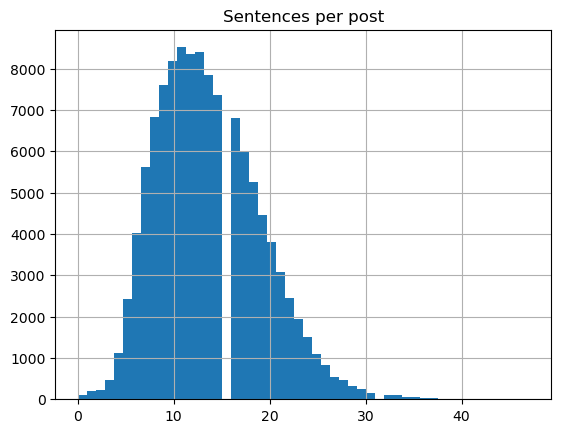

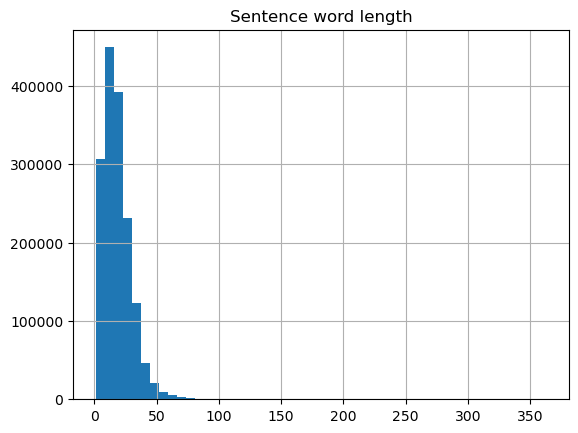

posts with n_sents < 2: 0.002673017940062713
posts with n_sents > 60: 0.0


In [51]:
import matplotlib.pyplot as plt
df = ds2['train'].to_pandas()

# 每条帖子的句子数量分布
df['n_sents'].hist(bins=50); plt.title('Sentences per post'); plt.show()

# 句子长度分布（词数）
all_wordlens = [w for rows in df['word_len'] for w in rows]
pd.Series(all_wordlens).hist(bins=50); plt.title('Sentence word length'); plt.show()

# 极端样本排查
print("posts with n_sents < 2:", (df['n_sents']<2).mean())
print("posts with n_sents > 60:", (df['n_sents']>60).mean())
